Starting Sweep (In-Memory Implementation)...
Testing 5x ratio (K_s=26214)... Done. Energy: 3753158932.48 pJ | Total compute: 0.069083 pJ/op (5468928 ops) | SM_Compute=0.100000 pJ/op (2097152 ops), PFU_Compute=0.020000 pJ/op (16384 ops), NMA_MAC_Compute=0.050000 pJ/op (3355392 ops)
Testing 10x ratio (K_s=13107)... 

/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Done. Energy: 2347585223.68 pJ | Total compute: 0.077528 pJ/op (3791232 ops) | SM_Compute=0.100000 pJ/op (2097152 ops), PFU_Compute=0.020000 pJ/op (16384 ops), NMA_MAC_Compute=0.050000 pJ/op (1677696 ops)
Testing 20x ratio (K_s=6553)... 

/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Done. Energy: 1644744750.08 pJ | Total compute: 0.085351 pJ/op (2952320 ops) | SM_Compute=0.100000 pJ/op (2097152 ops), PFU_Compute=0.020000 pJ/op (16384 ops), NMA_MAC_Compute=0.050000 pJ/op (838784 ops)
Testing 40x ratio (K_s=3276)... 

/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Done. Energy: 1293324513.28 pJ | Total compute: 0.091205 pJ/op (2532864 ops) | SM_Compute=0.100000 pJ/op (2097152 ops), PFU_Compute=0.020000 pJ/op (16384 ops), NMA_MAC_Compute=0.050000 pJ/op (419328 ops)


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


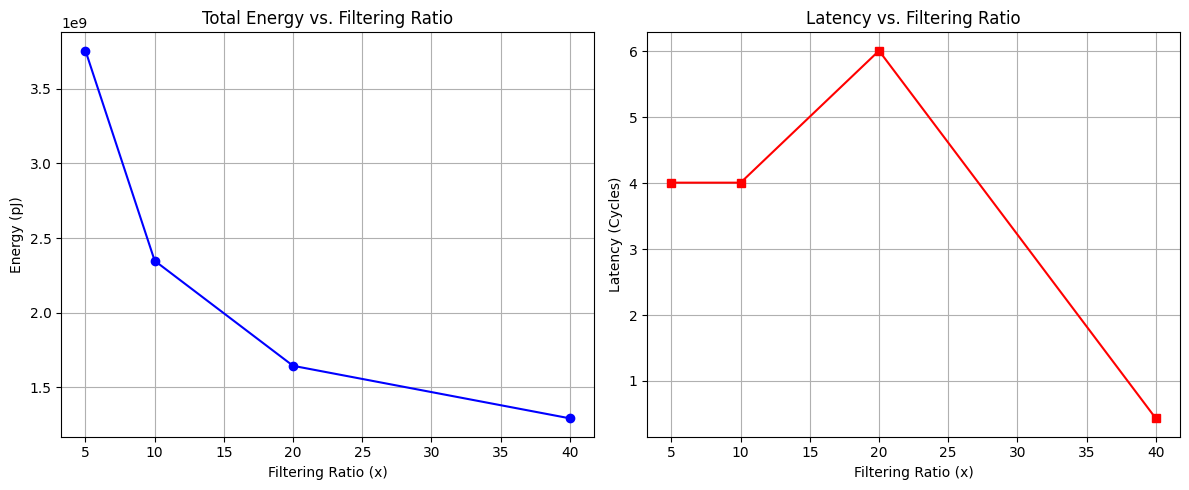

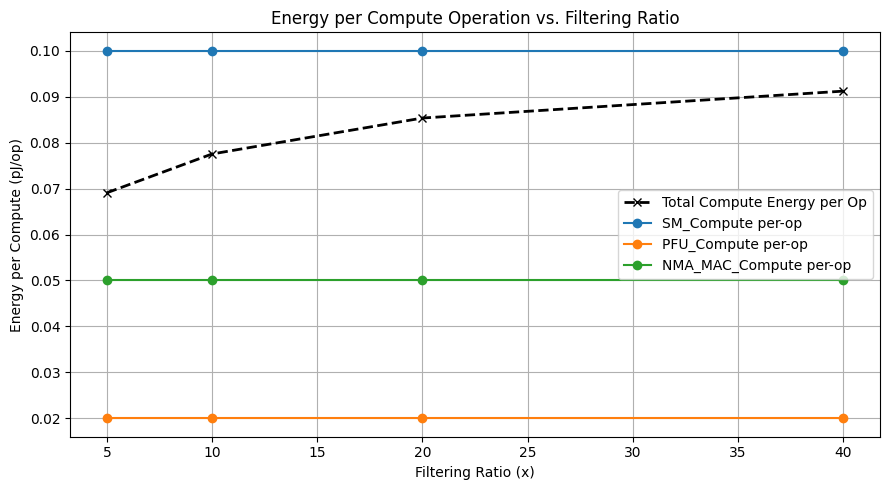

In [12]:
import matplotlib.pyplot as plt
import accelforge as af

# Configuration
PROB_FILE = 'prob.yaml'
ARCH_FILES = ["arch.yaml", "components.yaml", "map.yaml"]
TOTAL_KEYS = 131072

# Compute units to track for normalized compute energy
COMPUTE_UNITS = ["SM_Compute", "PFU_Compute", "NMA_MAC_Compute"]


def main():
    yaml_files = ARCH_FILES + [PROB_FILE]
    spec = af.Spec.from_yaml(yaml_files)

    filtering_ratios = [5, 10, 20, 40]
    energies = []
    latencies = []

    # pJ per compute-op for each compute unit
    compute_energy_per_op_history = {unit: [] for unit in COMPUTE_UNITS}
    # pJ per compute-op aggregated across all compute units
    total_energy_per_op_history = []

    print("Starting Sweep (In-Memory Implementation)...")

    for ratio in filtering_ratios:
        new_ks = int(TOTAL_KEYS / ratio)
        spec.workload.rank_sizes['K_s'] = new_ks

        print(f"Testing {ratio}x ratio (K_s={new_ks})...", end=" ", flush=True)

        try:
            mappings = spec.map_workload_to_arch(
                print_progress=False,
                print_number_of_pmappings=False
            )

            component_energy_j = mappings.energy(per_component=True)
            action_counts = mappings.actions(per_component=True)
            energy_pj = sum(component_energy_j.values()) * 1e12

            unit_ops = {}
            unit_energy_per_op = {}
            for unit in COMPUTE_UNITS:
                ops = action_counts.get((unit, 'compute'), 0.0)
                unit_ops[unit] = ops

                unit_energy_pj = component_energy_j.get(unit, 0.0) * 1e12
                unit_epop = unit_energy_pj / ops if ops else 0.0
                unit_energy_per_op[unit] = unit_epop
                compute_energy_per_op_history[unit].append(unit_epop)

            total_compute_ops = sum(unit_ops.values())
            total_compute_energy_pj = sum(component_energy_j.get(unit, 0.0) for unit in COMPUTE_UNITS) * 1e12
            total_epop = total_compute_energy_pj / total_compute_ops if total_compute_ops else 0.0
            total_energy_per_op_history.append(total_epop)

            try:
                cycles = mappings.cycles()
            except AttributeError:
                cycles = mappings.latency()

            energies.append(energy_pj)
            latencies.append(cycles)

            per_unit = ", ".join(
                f"{u}={unit_energy_per_op[u]:.6f} pJ/op ({int(unit_ops[u])} ops)"
                for u in COMPUTE_UNITS
            )
            print(
                f"Done. Energy: {energy_pj:.2f} pJ | "
                f"Total compute: {total_epop:.6f} pJ/op ({int(total_compute_ops)} ops) | {per_unit}"
            )

        except Exception as e:
            print(f"FAILED! Error: {e}")
            break

    # 5. Visualize the results
    if energies:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        ax1.plot(filtering_ratios[:len(energies)], energies, marker='o', color='blue')
        ax1.set_title('Total Energy vs. Filtering Ratio')
        ax1.set_xlabel('Filtering Ratio (x)')
        ax1.set_ylabel('Energy (pJ)')
        ax1.grid(True)

        ax2.plot(filtering_ratios[:len(latencies)], latencies, marker='s', color='red')
        ax2.set_title('Latency vs. Filtering Ratio')
        ax2.set_xlabel('Filtering Ratio (x)')
        ax2.set_ylabel('Latency (Cycles)')
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

        fig2, ax3 = plt.subplots(figsize=(9, 5))
        ax3.plot(
            filtering_ratios[:len(total_energy_per_op_history)],
            total_energy_per_op_history,
            marker='x',
            linestyle='--',
            color='black',
            linewidth=2,
            label='Total Compute Energy per Op'
        )

        for unit in COMPUTE_UNITS:
            ax3.plot(
                filtering_ratios[:len(compute_energy_per_op_history[unit])],
                compute_energy_per_op_history[unit],
                marker='o',
                label=f'{unit} per-op'
            )

        ax3.set_title('Energy per Compute Operation vs. Filtering Ratio')
        ax3.set_xlabel('Filtering Ratio (x)')
        ax3.set_ylabel('Energy per Compute (pJ/op)')
        ax3.grid(True)
        ax3.legend()

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

In [8]:
!which timeloop-model
!which accelforge

In [9]:
!find / -name "timeloop-model" -type f 2>/dev/null
!find / -name "accelforge" -type f 2>/dev/null